# 04 · Split, pipeline, baseline y modelos preliminares
**Proyecto Integrador – Data Mining Tools (CC209)** · TP1

Cubre los **Pasos 6 a 10**: separación de datos sin fuga, pipeline reproducible, baseline, modelos y evaluación.
Entrada: `data/interim/kc_house_clean.csv` (resultado del Paso 5).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INTERIM_FILE = ROOT / "data" / "interim" / "kc_house_clean.csv"
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
PROCESSED.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

df = pd.read_csv(INTERIM_FILE, dtype={"zipcode": "string"}, parse_dates=["fecha"])
print(f"{df.shape[0]:,} filas x {df.shape[1]} columnas")

21,613 filas x 27 columnas


---
## 6. Separación de datos y control de fuga de información

### 6.1 Evidencia previa: ¿tiene sentido un split temporal?

In [2]:
por_mes = (df.groupby(df["fecha"].dt.to_period("M"))["price"]
             .agg(ventas="size", mediana="median").round(0))
por_mes

,ventas,mediana
fecha,,
2014-05,1768,465000.0
2014-06,2180,465000.0
2014-07,2211,465000.0
2014-08,1940,442100.0
2014-09,1774,450000.0
2014-10,1878,446900.0
2014-11,1411,435000.0
2014-12,1471,432500.0
2015-01,978,438500.0


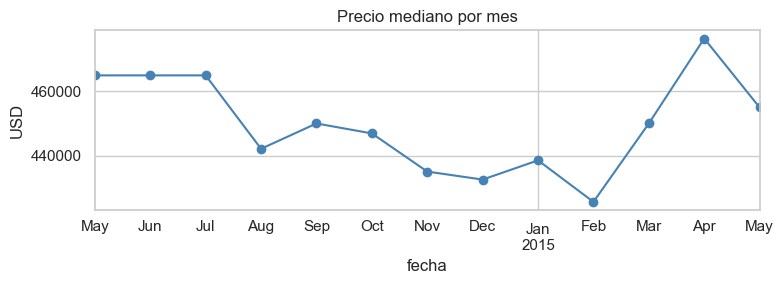

Un test temporal del 15 % final comenzaría el 2015-03-26 y solo cubriría primavera de 2015.
Precio mediano antes / después del corte: 449000.0 / 475000.0


In [3]:
por_mes["mediana"].plot(marker="o", figsize=(8, 3), title="Precio mediano por mes", color="steelblue")
plt.ylabel("USD")
plt.tight_layout()
plt.show()

corte = df["fecha"].quantile(.85)
print(f"Un test temporal del 15 % final comenzaría el {corte.date()} y solo cubriría primavera de 2015.")
print("Precio mediano antes / después del corte:",
      df.loc[df["fecha"] <= corte, "price"].median(), "/", df.loc[df["fecha"] > corte, "price"].median())

**Qué muestran los datos**
- El precio mediano mensual es bastante estable: oscila entre ~426 mil (feb 2015) y ~477 mil (abr 2015), una variación de ±5 % alrededor de 450 mil, con un repunte en primavera.
- Un split temporal dejaría como test solo las ventas desde fines de marzo de 2015 (mediana 475 mil, contra 449 mil antes).

**Decisión: split aleatorio agrupado por `id`, no temporal.**

**Justificación**
- Con solo ~13 meses no hay tendencia de largo plazo que el test deba medir, y el nivel de precios es estable.
- Un test temporal mediría el desempeño en una sola estación (primavera) y se confundiría con la estacionalidad.
- El modelo no usa la fecha como predictor (ver 6.4), por lo que no necesita extrapolar en el tiempo.

**Riesgo declarado:** un split aleatorio no mide qué tan bien funcionaría el modelo con ventas **futuras**. Este es un límite del dato y se menciona en las conclusiones. En el TF1 se puede añadir una validación temporal como prueba de robustez.

### 6.2 Estrategia: train / validation / test = 70 / 15 / 15, agrupado por `id`

| Partición | Uso |
|---|---|
| **Train (70 %)** | Ajustar transformaciones y modelos |
| **Validation (15 %)** | Comparar modelos y decidir (se puede consultar muchas veces) |
| **Test (15 %)** | Evaluación final, **una sola vez** |

**Por qué 70/15/15:** con ~21.6 mil filas, 15 % deja ~3 200 ventas para validación y para test, suficientes para métricas estables. Separar validación evita decidir con el test.

**Por qué agrupado por `id`:** una misma vivienda puede aparecer hasta 3 veces. Si quedara en *train* y en *test*, el modelo se evaluaría con casas que ya vio y el error parecería menor al real. `GroupShuffleSplit` mantiene todas las ventas de un `id` en la misma partición.

In [4]:
# 1) Se separa el test (15 %)
g1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
idx_trainval, idx_test = next(g1.split(df, groups=df["id"]))

# 2) Del resto se separa validation (15 % del total = 0.15 / 0.85 del resto)
sub = df.iloc[idx_trainval]
g2 = GroupShuffleSplit(n_splits=1, test_size=0.15 / 0.85, random_state=RANDOM_STATE)
rel_train, rel_val = next(g2.split(sub, groups=sub["id"]))
idx_train, idx_val = idx_trainval[rel_train], idx_trainval[rel_val]

split = pd.Series("", index=df.index, name="split")
split.iloc[idx_train] = "train"
split.iloc[idx_val] = "val"
split.iloc[idx_test] = "test"

resumen = split.value_counts().rename("filas").to_frame()
resumen["proporción"] = (resumen["filas"] / len(df)).round(3)
resumen.loc[["train", "val", "test"]]

,filas,proporción
split,,
train,15130,0.70
val,3242,0.15
test,3241,0.15


### 6.3 Verificaciones anti-fuga

In [5]:
ids = df.groupby(split)["id"].apply(set)
solapes = {
    "train ∩ val": len(ids["train"] & ids["val"]),
    "train ∩ test": len(ids["train"] & ids["test"]),
    "val ∩ test": len(ids["val"] & ids["test"]),
}
print("id compartidos entre particiones:", solapes)
assert all(v == 0 for v in solapes.values()), "Hay fuga: un id aparece en dos particiones"

rep = df[df["id"].duplicated(keep=False)]
n_dividido = (rep.groupby("id").apply(lambda g: split[g.index].nunique()) > 1).sum()
print("Viviendas repetidas repartidas en más de una partición:", n_dividido)
assert n_dividido == 0

zip_train = set(df.loc[split == "train", "zipcode"])
for nombre in ["val", "test"]:
    fuera = df[(split == nombre) & ~df["zipcode"].isin(zip_train)]
    print(f"{nombre}: filas con zipcode ausente en train = {len(fuera)}")

id compartidos entre particiones: {'train ∩ val': 0, 'train ∩ test': 0, 'val ∩ test': 0}
Viviendas repetidas repartidas en más de una partición: 0


val: filas con zipcode ausente en train = 0
test: filas con zipcode ausente en train = 0


### 6.4 ¿Las particiones son comparables?

In [6]:
comparacion = df.groupby(split)["price"].describe(percentiles=[.1, .5, .9]).loc[["train", "val", "test"]]
display(comparacion[["count", "mean", "10%", "50%", "90%", "max"]].round(0))

otras = df.groupby(split).agg(
    waterfront=("waterfront", "mean"),
    sqft_living_mediana=("sqft_living", "median"),
    dato_dudoso=("dato_dudoso", "sum"),
).loc[["train", "val", "test"]]
otras["waterfront"] = otras["waterfront"].round(4)
otras

,count,mean,10%,50%,90%,max
split,,,,,,
train,15130.0,538673.0,246690.0,450000.0,880000.0,7700000.0
val,3242.0,533999.0,245000.0,445975.0,870000.0,4668000.0
test,3241.0,552785.0,244000.0,453000.0,921000.0,6885000.0


,waterfront,sqft_living_mediana,dato_dudoso
split,,,
train,0.0073,1920.0,5
val,0.0093,1880.0,4
test,0.0071,1920.0,1


**Qué muestran los datos**
- Tamaños: **15 130** (train), **3 242** (val) y **3 241** (test), es decir 70/15/15.
- **Ningún `id` aparece en más de una partición**, y las 176 viviendas repetidas quedaron completas en una sola.
- Todos los códigos postales de validación y test existen en train.
- La mediana del precio es parecida entre particiones (~446 mil a 453 mil). La media del test (553 mil) es algo mayor que la de train (539 mil) porque contiene algunas ventas muy caras. El precio máximo de todo el dataset (7.7 millones) cayó en train.

**Interpretación**
- Las diferencias de media son esperables en una muestra con cola larga y no indican un split defectuoso. Aun así, se debe recordar que las métricas en dólares de test pueden verse algo afectadas por pocos casos extremos; por eso se usarán también métricas relativas.
- No se estratificó por precio ni por zona: el tamaño de cada partición y la cobertura de zonas hacen que no sea necesario. Es una decisión revisable.

**Variables fuera de los predictores (control de fuga)**
- `id`: solo sirve para agrupar.
- `fecha`, `anio_venta`, `mes_venta`: no se usan; con 13 meses el modelo no podría generalizar un efecto temporal y se confundiría con estacionalidad.
- `dato_dudoso`: es un indicador de calidad de datos, no una característica de la vivienda.
- No existe ninguna variable derivada del precio (se descartó `precio_por_pie2` en el Paso 5).

In [7]:
split.rename_axis("fila").reset_index().to_csv(PROCESSED / "split.csv", index=False)
print("Índices guardados en", (PROCESSED / "split.csv").relative_to(ROOT))

Índices guardados en data\processed\split.csv


**Reglas de uso a partir de aquí**
1. Todo ajuste (imputación, escalado, codificación, modelos) usa **solo train**.
2. **Validation** se usa para comparar y decidir.
3. **Test** no se usa para ajustar ni para decidir; solo se mide en la evaluación final del Paso 10. (En 6.4 solo se compararon estadísticas descriptivas del precio, sin tomar decisiones de modelado a partir de ellas.)
4. La partición es reproducible: `RANDOM_STATE = 42` y los índices están en `data/processed/split.csv`.

---
## 7. Pipeline reproducible de preprocesamiento

### 7.1 Qué se hace con cada variable

| Grupo | Variables | Transformación | Por qué |
|---|---|---|---|
| Superficies (asimétricas) | `sqft_living`, `sqft_lot`, `sqft_above`, `sqft_basement`, `sqft_living15`, `sqft_lot15` | `log1p` → `StandardScaler` | Asimetría alta (EDA 4.2); `log1p` admite el 0 de `sqft_basement` |
| Conteos con faltantes | `bedrooms`, `bathrooms` | `SimpleImputer(mediana)` → `StandardScaler` | 10 y 5 faltantes creados en el Paso 5; la mediana se calcula **solo con train** |
| Numéricas / ordinales | `floors`, `view`, `condition`, `grade`, `antiguedad`, `lat`, `long` | `StandardScaler` | Escala comparable para el modelo lineal |
| Binarias | `waterfront`, `renovada`, `tiene_sotano` | Sin cambios | Ya son 0/1 |
| Categórica | `zipcode` | `OneHotEncoder(handle_unknown="ignore")` | Es una categoría de 70 niveles; un código desconocido no rompe la predicción |
| **Objetivo** | `price` | `log` al ajustar, `exp` al predecir | Asimetría 4.0 → 0.43 (EDA 4.1) |
| **Excluidas** | `id`, `fecha`, `anio_venta`, `mes_venta`, `dato_dudoso`, `yr_built`, `yr_renovated` | — | Ver 6.4. `yr_built` y `yr_renovated` quedan representadas por `antiguedad` y `renovada` |

**Cuándo se ajusta cada cosa:** todos los parámetros (medianas, medias, desviaciones, categorías) se aprenden en `fit` con **train**. Validation y test solo pasan por `transform`.

**Un solo preprocesador para todos los modelos:** el `log1p` y el escalado no afectan a los modelos de árboles, y usar el mismo flujo garantiza una comparación justa entre modelos.

In [8]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

COLS_LOG = ["sqft_living", "sqft_lot", "sqft_above", "sqft_basement", "sqft_living15", "sqft_lot15"]
COLS_IMPUTAR = ["bedrooms", "bathrooms"]
COLS_NUM = ["floors", "view", "condition", "grade", "antiguedad", "lat", "long"]
COLS_BIN = ["waterfront", "renovada", "tiene_sotano"]
COLS_CAT = ["zipcode"]
FEATURES = COLS_LOG + COLS_IMPUTAR + COLS_NUM + COLS_BIN + COLS_CAT
TARGET = "price"


def crear_preprocesador():
    return ColumnTransformer(
        transformers=[
            ("log", Pipeline([
                ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                ("escala", StandardScaler()),
            ]), COLS_LOG),
            ("imputar", Pipeline([
                ("imputador", SimpleImputer(strategy="median")),
                ("escala", StandardScaler()),
            ]), COLS_IMPUTAR),
            ("num", StandardScaler(), COLS_NUM),
            ("bin", "passthrough", COLS_BIN),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), COLS_CAT),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def crear_pipeline(estimador):
    """Preprocesamiento + modelo, con objetivo en escala log."""
    return TransformedTargetRegressor(
        regressor=Pipeline([("prep", crear_preprocesador()), ("modelo", estimador)]),
        func=np.log,
        inverse_func=np.exp,
    )


mask_train = (split == "train").to_numpy()
mask_val = (split == "val").to_numpy()
mask_test = (split == "test").to_numpy()

X_train, y_train = df.loc[mask_train, FEATURES], df.loc[mask_train, TARGET]
X_val, y_val = df.loc[mask_val, FEATURES], df.loc[mask_val, TARGET]
X_test, y_test = df.loc[mask_test, FEATURES], df.loc[mask_test, TARGET]

print("Predictores:", len(FEATURES), "| train:", X_train.shape, "| val:", X_val.shape, "| test:", X_test.shape)

Predictores: 19 | train: (15130, 19) | val: (3242, 19) | test: (3241, 19)


### 7.2 Verificaciones del pipeline

In [9]:
prep = crear_preprocesador()
Xt_train = prep.fit_transform(X_train)          # fit SOLO con train
Xt_val = prep.transform(X_val)                  # val: solo transform
Xt_test = prep.transform(X_test)                # test: solo transform

nombres = prep.get_feature_names_out()
print("Columnas tras el preprocesamiento:", len(nombres), "(6 log + 2 imputadas + 7 num + 3 bin + 70 zipcode)")
print("Formas  train / val / test:", Xt_train.shape, Xt_val.shape, Xt_test.shape)
print("NaN tras el preprocesamiento:", int(np.isnan(Xt_train).sum() + np.isnan(Xt_val).sum() + np.isnan(Xt_test).sum()))

Columnas tras el preprocesamiento: 88 (6 log + 2 imputadas + 7 num + 3 bin + 70 zipcode)
Formas  train / val / test: (15130, 88) (3242, 88) (3241, 88)
NaN tras el preprocesamiento: 0


In [10]:
# Los parámetros aprendidos vienen de train, no del dataset completo
mediana_train = X_train["bedrooms"].median()
mediana_todo = df["bedrooms"].median()
imputador = prep.named_transformers_["imputar"].named_steps["imputador"]
print("Mediana de bedrooms usada por el imputador:", imputador.statistics_[0], "| mediana de train:", mediana_train)

escala = prep.named_transformers_["log"].named_steps["escala"]
media_train = np.log1p(X_train["sqft_living"]).mean()
media_todo = np.log1p(df["sqft_living"]).mean()
print(f"Media de log1p(sqft_living) usada: {escala.mean_[0]:.6f} | train: {media_train:.6f} | dataset completo: {media_todo:.6f}")
assert np.isclose(escala.mean_[0], media_train)
assert not np.isclose(escala.mean_[0], media_todo, atol=1e-9), "Los parámetros coinciden con el dataset completo: posible fuga"

# Un código postal nunca visto no debe romper la predicción
nuevo = X_train.iloc[[0]].copy()
nuevo["zipcode"] = "99999"
print("Código postal desconocido -> columnas zipcode activas:", int(prep.transform(nuevo)[:, -70:].sum()))

Mediana de bedrooms usada por el imputador: 3.0 | mediana de train: 3.0
Media de log1p(sqft_living) usada: 7.551356 | train: 7.551356 | dataset completo: 7.550910
Código postal desconocido -> columnas zipcode activas: 0


**Qué muestran los datos**
- El preprocesamiento produce **88 columnas** (18 numéricas/binarias + 70 de `zipcode`), sin ningún `NaN`.
- El imputador usa la mediana de **train** (3.0), que coincide con la del dataset completo; por eso esa comparación no prueba nada por sí sola.
- La prueba concluyente es la del escalador: su media de `log1p(sqft_living)` es 7.551356, igual a la de train y distinta de la del dataset completo (7.550910). La diferencia es pequeña, pero confirma que el ajuste no usó validation ni test.
- Un código postal desconocido produce un vector de ceros en `zipcode` en vez de un error.

**Interpretación**
- El flujo es reproducible: todo el preprocesamiento está en un objeto único (`ColumnTransformer` dentro de un `Pipeline`), y el objetivo se transforma con `TransformedTargetRegressor`. Al predecir se devuelve el precio en USD.
- Como el imputador y el escalador son parte del pipeline, la validación cruzada del TF1 volverá a ajustarlos en cada pliegue sin esfuerzo adicional.

**Riesgo:** `zipcode` con *one-hot* agrega 70 columnas dispersas. Funciona bien con modelos lineales regularizados y con Random Forest, pero se revisará si estorba (por ejemplo, para XGBoost) o si conviene reemplazarlo por `lat`/`long` o por zonas de clustering (TF1).

---
## 8. Baseline

> *¿El modelo propuesto mejora realmente frente a una solución trivial o simple?*

Se comparan tres referencias de dificultad creciente. **La más fuerte es la que cualquier modelo debe superar.**

| Baseline | Qué hace | Para qué sirve |
|---|---|---|
| **B1 · Mediana global** | Predice siempre el precio mediano de train | Piso absoluto: "sin información" |
| **B2 · Lineal simple** | Regresión de `log(price)` sobre `log1p(sqft_living)` | ¿Basta con el tamaño? |
| **B3 · Regla por zona** | Precio por pie² mediano del código postal (de train) × `sqft_living` | Regla de tasación realista: zona + tamaño |

### 8.1 Métricas
| Métrica | Por qué |
|---|---|
| **MAE** (USD) | Error absoluto promedio, fácil de interpretar |
| **RMSE** (USD) | Penaliza más los errores grandes (ventas caras) |
| **R²** (USD) y **R²** (log) | Proporción de variación explicada, en dólares y en escala log |
| **MdAPE** (%) | **Error porcentual mediano.** Es la métrica del criterio de utilidad (≤ 15 %); un error en dólares engaña entre casas de 150 mil y de 3 millones |
| **% dentro de ±20 %** | Proporción de ventas estimadas con un error relativo menor a 20 % |

In [11]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluar(y_real, y_pred):
    y_real, y_pred = np.asarray(y_real, float), np.asarray(y_pred, float)
    ape = np.abs(y_pred - y_real) / y_real
    return {
        "MAE (USD)": mean_absolute_error(y_real, y_pred),
        "RMSE (USD)": np.sqrt(mean_squared_error(y_real, y_pred)),
        "R² (USD)": r2_score(y_real, y_pred),
        "R² (log)": r2_score(np.log(y_real), np.log(y_pred)),
        "MdAPE (%)": 100 * np.median(ape),
        "± 20 % (%)": 100 * np.mean(ape <= 0.20),
    }


resultados_val = {}
pred_val = {}

In [12]:
# B1 · Mediana global (la mediana se calcula con train)
b1 = crear_pipeline(DummyRegressor(strategy="median")).fit(X_train, y_train)
pred_val["B1 · Mediana global"] = b1.predict(X_val)

# B2 · Lineal simple sobre log1p(sqft_living)
b2 = TransformedTargetRegressor(
    regressor=Pipeline([
        ("x", ColumnTransformer([("tam", FunctionTransformer(np.log1p), ["sqft_living"])])),
        ("lineal", LinearRegression()),
    ]),
    func=np.log, inverse_func=np.exp,
).fit(X_train, y_train)
pred_val["B2 · Lineal simple (sqft_living)"] = b2.predict(X_val)

# B3 · Regla por zona: precio por pie² mediano del código postal (train) × sqft_living
ppp_zona = (y_train / X_train["sqft_living"]).groupby(X_train["zipcode"]).median()
ppp_global = (y_train / X_train["sqft_living"]).median()
def regla_zona(X):
    return X["zipcode"].map(ppp_zona).fillna(ppp_global).to_numpy() * X["sqft_living"].to_numpy()
pred_val["B3 · Regla por zona (USD/pie² × tamaño)"] = regla_zona(X_val)

for nombre, p in pred_val.items():
    resultados_val[nombre] = evaluar(y_val, p)

pd.DataFrame(resultados_val).T.round(2)

,MAE (USD),RMSE (USD),R² (USD),R² (log),MdAPE (%),± 20 % (%)
B1 · Mediana global,219515.32,368055.03,-0.05,-0.00,34.31,29.89
B2 · Lineal simple (sqft_living),166401.25,273689.11,0.42,0.46,26.23,38.25
B3 · Regla por zona (USD/pie² × tamaño),100340.24,173632.26,0.77,0.78,14.29,64.22


**Qué muestran los datos (validation)**

| Baseline | MAE | MdAPE | R² (USD) | ± 20 % |
|---|---|---|---|---|
| B1 · Mediana global | 219 515 | 34.3 % | −0.05 | 29.9 % |
| B2 · Lineal simple | 166 401 | 26.2 % | 0.42 | 38.3 % |
| **B3 · Regla por zona** | **100 340** | **14.3 %** | **0.77** | **64.2 %** |

- B1 no explica nada (R² ≈ 0) y se equivoca 34 % en la mediana: es el piso esperado.
- Solo con el tamaño (B2) el error mediano baja a 26 %.
- Agregar la **zona** (B3) reduce el MAE a la mitad de B2 (166 mil → 100 mil) y el error mediano a 14.3 %.

**Interpretación**
- Tamaño y ubicación explican la mayor parte del precio: una regla de dos ingredientes ya llega a R² 0.77. **B3 es el baseline que hay que superar.**
- Esto confirma con datos el hallazgo del EDA sobre el peso de la ubicación.

### 8.2 Revisión del criterio de utilidad del Paso 2
El Paso 2 fijó MdAPE ≤ 15 % como umbral y avisó que se revisaría con la evidencia del baseline.

- **Evidencia:** B3, una regla sin modelo de aprendizaje, ya logra **14.3 %**. El umbral de 15 % **no demuestra que un modelo aporte valor**.
- **Qué criterio manda:** el de *mejora sobre el baseline más fuerte (B3)*. Antes de ver ningún modelo se fija su definición operativa:

> **Un modelo se considera útil si, en validation, reduce el MAE y el MdAPE de B3 en al menos un 15 % relativo** (es decir, MAE ≤ ~85 mil y MdAPE ≤ ~12.1 %).

- El 15 % relativo es una propuesta de trabajo, **a validar con el grupo**. El umbral absoluto de MdAPE ≤ 15 % se mantiene como requisito mínimo, no como prueba de utilidad.